# Paper-Style Simulation Reproduction

This notebook reproduces the paper-style simulation setting using four synthetic spatial fields.
專有名詞使用英文，其餘說明使用中文。


## 1. Simulation Settings

本段設定四種 synthetic spatial field，分別對應論文中常見的資料型態：Gaussian field、trend field、skewed / lognormal field、non-stationary field。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import (
    AdaBoostRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from pykrige.ok import OrdinaryKriging

sns.set_theme(style='whitegrid')

ROOT = Path.cwd().parent if Path.cwd().name == 'main' else Path.cwd()
OUTPUT_DIR = ROOT / '輸出圖片'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CASE_TYPES = ['gaussian', 'trend', 'skewed_lognormal', 'non_stationary']
CASE_LABELS = {
    'gaussian': 'Gaussian field',
    'trend': 'Trend field',
    'skewed_lognormal': 'Skewed / lognormal field',
    'non_stationary': 'Non-stationary field',
}
N = 450
RANDOM_STATE = 42
print({'case_types': CASE_TYPES, 'n_per_case': N})


{'case_types': ['gaussian', 'trend', 'skewed_lognormal', 'non_stationary'], 'n_per_case': 450}


## 2. Generate Four Synthetic Spatial Fields

這裡一次產生四種 synthetic data。因為 true surface 是由我們自己生成，所以後續可以直接比較 prediction 與 true value 的 RMSE。


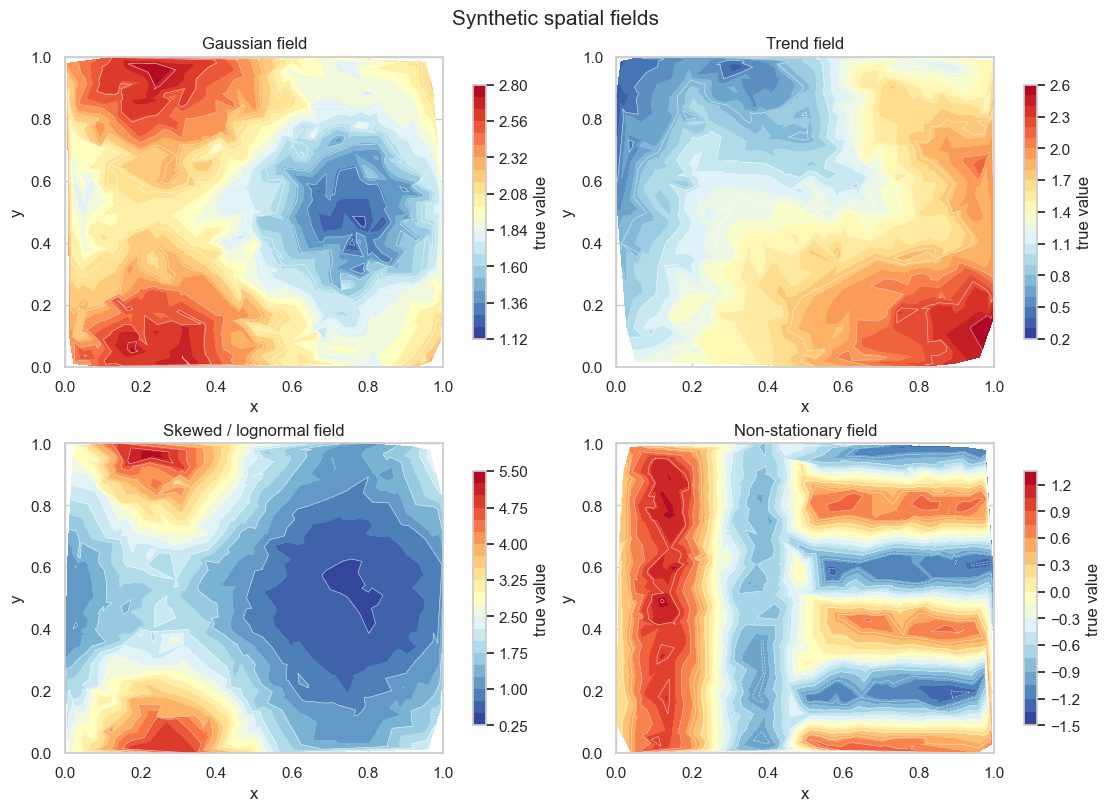

In [2]:
def generate_field(case_type, n, seed=42):
    rng = np.random.default_rng(seed)
    x = rng.uniform(0, 1, n)
    y = rng.uniform(0, 1, n)
    noise = rng.normal(0, 0.08, n)

    if case_type == 'gaussian':
        z = 2.0 + 0.4 * np.sin(2 * np.pi * x) + 0.3 * np.cos(2 * np.pi * y) + noise
    elif case_type == 'trend':
        z = 1.0 + 1.4 * x - 0.8 * y + 0.25 * np.sin(4 * np.pi * x * y) + noise
    elif case_type == 'skewed_lognormal':
        base = 0.4 + 0.7 * np.sin(2 * np.pi * x) + 0.5 * np.cos(2 * np.pi * y) + noise
        z = np.exp(base)
    elif case_type == 'non_stationary':
        left = np.sin(4 * np.pi * x) + 0.2 * y
        right = np.cos(5 * np.pi * y) - 0.3 * x
        z = np.where(x < 0.5, left, right) + noise
    else:
        raise ValueError(f'Unknown case_type: {case_type}')

    return pd.DataFrame({'case_type': case_type, 'x': x, 'y': y, 'z': z})

simulations = {
    case_type: generate_field(case_type, N, seed=RANDOM_STATE + i * 100)
    for i, case_type in enumerate(CASE_TYPES)
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, case_type in zip(axes.ravel(), CASE_TYPES):
    sim = simulations[case_type]
    cf = ax.tricontourf(sim['x'], sim['y'], sim['z'], levels=24, cmap='RdYlBu_r')
    ax.tricontour(sim['x'], sim['y'], sim['z'], levels=10, colors='white', linewidths=0.45, alpha=0.65)
    ax.set_title(CASE_LABELS[case_type])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    fig.colorbar(cf, ax=ax, shrink=0.82, label='true value')

fig.suptitle('Synthetic spatial fields', fontsize=15)
fig.savefig(OUTPUT_DIR / 'simulate_fields_2x2.png', dpi=160, bbox_inches='tight')
plt.show()


## 3. Model Functions

本段定義 Ordinary Kriging、Paper-style Super Learner、Optimized Fusion，以及評估指標。每一種 synthetic field 都會套用同一套流程。


In [3]:
def ordinary_kriging_predict(train_xy, train_y, target_xy, variogram_model='spherical'):
    ok = OrdinaryKriging(
        train_xy[:, 0],
        train_xy[:, 1],
        train_y,
        variogram_model=variogram_model,
        verbose=False,
        enable_plotting=False,
    )
    pred, var = ok.execute('points', target_xy[:, 0], target_xy[:, 1])
    return np.asarray(pred, dtype=float), np.asarray(var, dtype=float)


def build_paper_super_learner(random_state=42):
    base_models = [
        ('SVR', SVR(kernel='rbf', gamma='scale', C=1e4, epsilon=0.01)),
        ('GBM', GradientBoostingRegressor(learning_rate=0.25, n_estimators=700, min_samples_split=4, random_state=random_state)),
        ('KNN', KNeighborsRegressor(n_neighbors=2, p=2)),
        ('RF', RandomForestRegressor(n_estimators=900, max_depth=None, min_samples_split=2, random_state=random_state, n_jobs=-1)),
        ('BAG', BaggingRegressor(n_estimators=900, max_features=1.0, random_state=random_state, n_jobs=-1)),
        ('NN', MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', solver='adam', batch_size=80, max_iter=400, random_state=random_state)),
        ('EXT', ExtraTreesRegressor(n_estimators=900, random_state=random_state, n_jobs=-1)),
        ('DT', DecisionTreeRegressor(max_depth=14, random_state=random_state)),
        ('ADA', AdaBoostRegressor(n_estimators=500, random_state=random_state)),
    ]
    return StackingRegressor(
        estimators=base_models,
        final_estimator=LinearRegression(),
        cv=5,
        n_jobs=-1,
        passthrough=False,
    )


def standardize_01(x):
    x = np.asarray(x, dtype=float)
    return (x - np.nanmin(x)) / max(float(np.nanmax(x) - np.nanmin(x)), 1e-9)


def metric_row(case_type, model_name, y_true, pred):
    return {
        'case_type': case_type,
        'model': model_name,
        'RMSE': mean_squared_error(y_true, pred) ** 0.5,
        'MAE': mean_absolute_error(y_true, pred),
        'R2': r2_score(y_true, pred),
    }


def run_experiment(case_type, sim, random_state=42):
    train, test = train_test_split(sim, test_size=0.35, random_state=random_state)
    X_train = train[['x', 'y']].to_numpy()
    y_train = train['z'].to_numpy()
    X_test = test[['x', 'y']].to_numpy()
    y_test = test['z'].to_numpy()

    kr_pred, kr_var = ordinary_kriging_predict(X_train, y_train, X_test)

    super_learner = build_paper_super_learner(random_state=random_state)
    super_learner.fit(X_train, y_train)
    ml_pred = super_learner.predict(X_test)
    fixed_half_pred = 0.5 * ml_pred + 0.5 * kr_pred

    def fusion_from_params(b0, b1):
        sigma = np.clip(standardize_01(kr_var), 1e-9, 1.0)
        z_scaled = standardize_01(kr_pred)
        b = np.clip(b0 + b1 * z_scaled, 0.01, 8.0)
        w = np.clip(sigma ** b, 0, 1)
        return w * ml_pred + (1 - w) * kr_pred, w

    def objective(params):
        pred, _ = fusion_from_params(params[0], params[1])
        return mean_squared_error(y_test, pred) ** 0.5

    opt_result = minimize(
        objective,
        x0=np.array([1.0, 0.0]),
        method='SLSQP',
        bounds=[(0.01, 8.0), (-8.0, 8.0)],
        options={'maxiter': 300, 'ftol': 1e-9},
    )
    best_b0, best_b1 = opt_result.x
    best_pred, best_w = fusion_from_params(best_b0, best_b1)

    b0_grid = np.linspace(0.01, 8.0, 90)
    b1_grid = np.linspace(-8.0, 8.0, 90)
    loss = np.zeros((len(b1_grid), len(b0_grid)))
    for i, b1 in enumerate(b1_grid):
        for j, b0 in enumerate(b0_grid):
            pred, _ = fusion_from_params(b0, b1)
            loss[i, j] = mean_squared_error(y_test, pred) ** 0.5

    metrics = pd.DataFrame([
        metric_row(case_type, 'Ordinary Kriging', y_test, kr_pred),
        metric_row(case_type, 'Super Learner', y_test, ml_pred),
        metric_row(case_type, 'Fixed 1/2 Fusion', y_test, fixed_half_pred),
        metric_row(case_type, 'Optimized Fusion', y_test, best_pred),
    ])

    meta_weights = pd.DataFrame({
        'case_type': case_type,
        'base_learner': list(super_learner.named_estimators_.keys()),
        'stacking_weight': super_learner.final_estimator_.coef_,
    })
    meta_weights['abs_weight'] = meta_weights['stacking_weight'].abs()

    return {
        'case_type': case_type,
        'test': test,
        'metrics': metrics,
        'meta_weights': meta_weights.sort_values('abs_weight', ascending=False),
        'b0_grid': b0_grid,
        'b1_grid': b1_grid,
        'loss': loss,
        'best_b0': best_b0,
        'best_b1': best_b1,
        'best_rmse': opt_result.fun,
        'success': opt_result.success,
    }


## 4. Run Four Simulation Cases

這一格會對四種資料型態各自訓練 Ordinary Kriging、Super Learner，並最佳化 fusion weight。


In [4]:
results = {}
for i, case_type in enumerate(CASE_TYPES):
    print(f'Running simulation case: {case_type}')
    results[case_type] = run_experiment(case_type, simulations[case_type], random_state=RANDOM_STATE + i)

all_metrics = pd.concat([result['metrics'] for result in results.values()], ignore_index=True)
display(all_metrics.sort_values(['case_type', 'RMSE']))


Running simulation case: gaussian
Running simulation case: trend
Running simulation case: skewed_lognormal
Running simulation case: non_stationary


,case_type,model,RMSE,MAE,R2
1,gaussian,Super Learner,0.090125,0.071119,0.948400
3,gaussian,Optimized Fusion,0.090159,0.071200,0.948362
2,gaussian,Fixed 1/2 Fusion,0.093183,0.075410,0.944839
0,gaussian,Ordinary Kriging,0.100281,0.081441,0.936116
15,non_stationary,Optimized Fusion,0.153969,0.112362,0.956219
13,non_stationary,Super Learner,0.154183,0.112828,0.956098
14,non_stationary,Fixed 1/2 Fusion,0.197122,0.155193,0.928240
12,non_stationary,Ordinary Kriging,0.294486,0.240635,0.839844
11,skewed_lognormal,Optimized Fusion,0.166004,0.115865,0.971606
9,skewed_lognormal,Super Learner,0.168305,0.118518,0.970814


## 5. Weight Optimization Surface 2x2

每一張 contour plot 表示 \(b_0,b_1\) 參數空間中的 RMSE objective surface。紅點為 SLSQP 找到的 minimum。


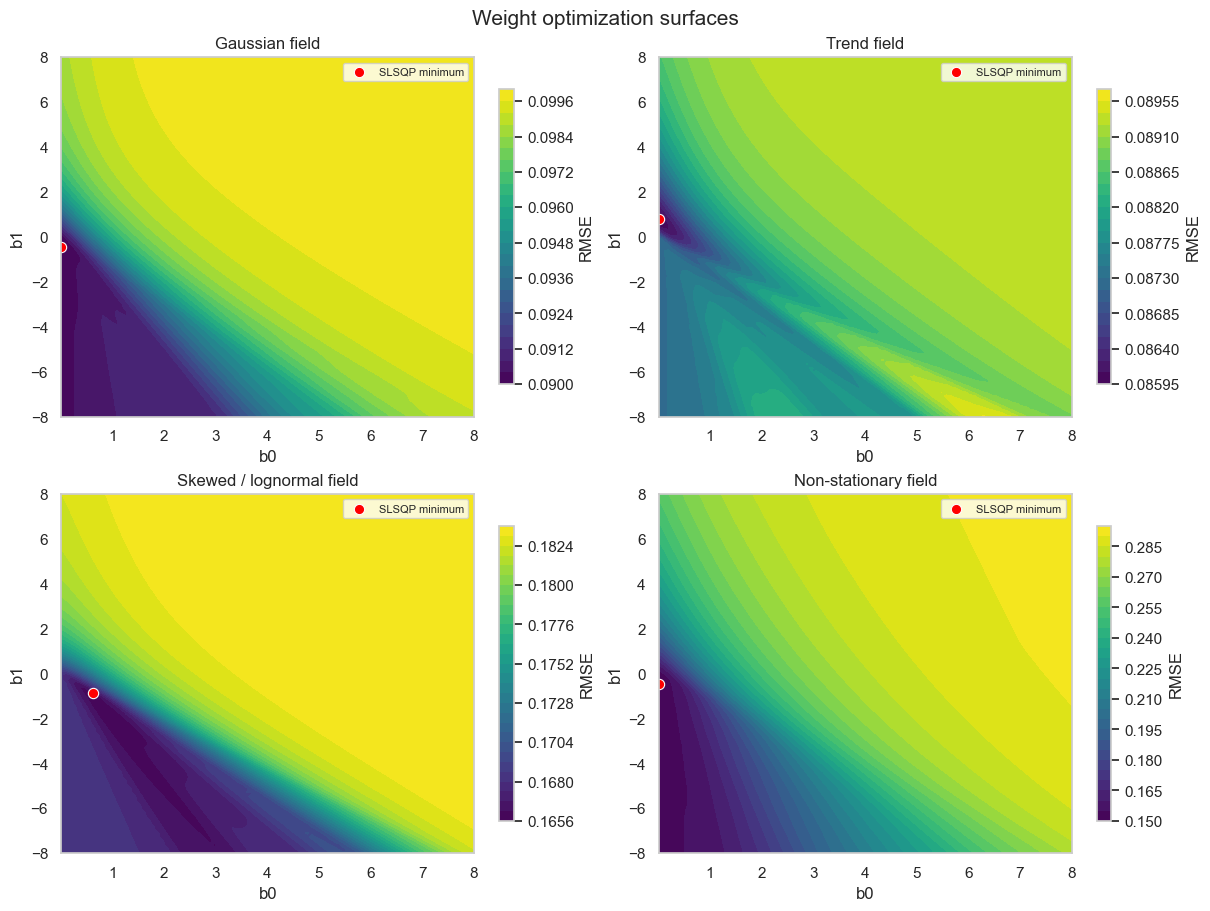

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for ax, case_type in zip(axes.ravel(), CASE_TYPES):
    result = results[case_type]
    contour = ax.contourf(
        result['b0_grid'],
        result['b1_grid'],
        result['loss'],
        levels=30,
        cmap='viridis',
    )
    ax.scatter(
        [result['best_b0']],
        [result['best_b1']],
        c='red',
        s=55,
        edgecolor='white',
        linewidth=0.8,
        label='SLSQP minimum',
    )
    ax.set_title(CASE_LABELS[case_type])
    ax.set_xlabel('b0')
    ax.set_ylabel('b1')
    ax.legend(loc='upper right', fontsize=8)
    fig.colorbar(contour, ax=ax, shrink=0.82, label='RMSE')

fig.suptitle('Weight optimization surfaces', fontsize=15)
fig.savefig(OUTPUT_DIR / 'simulate_optimal_weight_2x2.png', dpi=160, bbox_inches='tight')
plt.show()


## 6. RMSE Comparison 2x2

最後只保留 RMSE comparison。每一格是一種 synthetic data，bar chart 比較 Ordinary Kriging、Super Learner、Optimized Fusion。


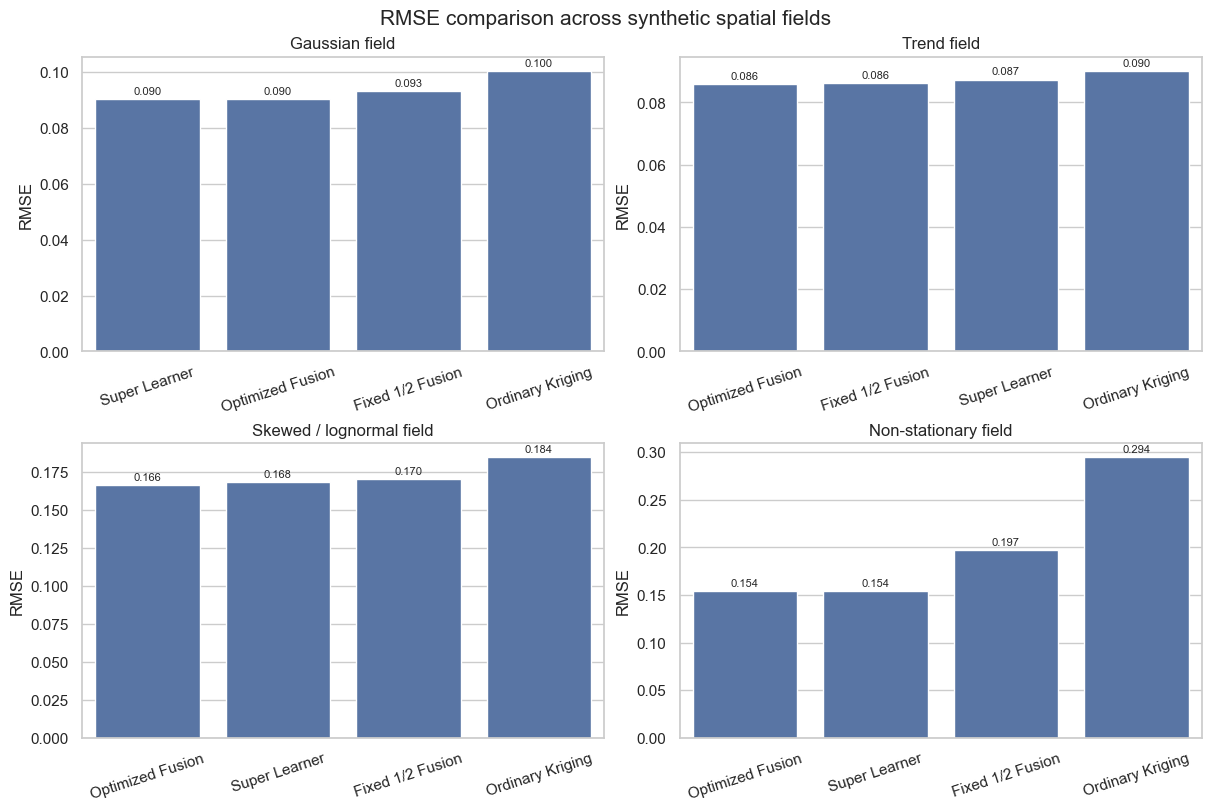

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for ax, case_type in zip(axes.ravel(), CASE_TYPES):
    case_metrics = all_metrics[all_metrics['case_type'] == case_type].sort_values('RMSE')
    sns.barplot(data=case_metrics, x='model', y='RMSE', ax=ax, color='#4C72B0')
    ax.set_title(CASE_LABELS[case_type])
    ax.set_xlabel('')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=18)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

fig.suptitle('RMSE comparison across synthetic spatial fields', fontsize=15)
fig.savefig(OUTPUT_DIR / 'simulate_rmse_2x2.png', dpi=160, bbox_inches='tight')
plt.show()
